## [Embedding](https://docs.langchain.com/oss/python/integrations/text_embedding/index#embedding-models)

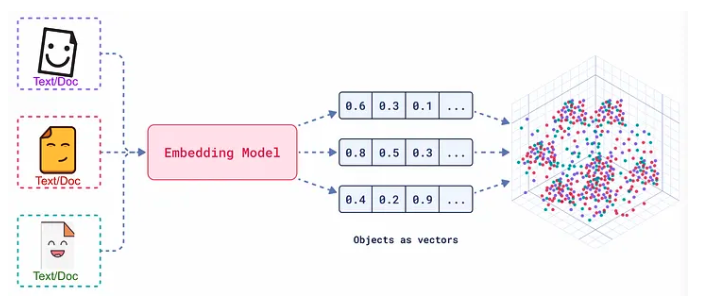

- 임베딩(Embedding)은 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정을 말합니다.
- 이러한 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 되며, 이를 통해 텍스트 간의 유사성을 계산하거나, 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업을 수행할 수 있습니다.
- 임베딩 과정은 텍스트의 의미적인 정보를 보존하도록 설계되어 있어, 벡터 공간에서 가까이 위치한 텍스트 조각들은 의미적으로도 유사한 것으로 간주됩니다.

임베딩의 주요 활용 사례:
- `의미 검색(Semantic Search)`: 벡터 표현을 활용하여 의미적으로 유사한 텍스트를 검색하는 과정으로, 사용자가 입력한 쿼리에 대해 가장 관련성 높은 문서나 정보를 찾아내는 데 사용됩니다.
- `문서 분류(Document Classification)`: 임베딩된 텍스트 벡터를 사용하여 문서를 특정 카테고리나 주제에 할당하는 분류 작업에 사용됩니다.
- `텍스트 유사도 계산(Text Similarity Calculation)`: 두 텍스트 벡터 사이의 거리를 계산하여, 텍스트 간의 유사성 정도를 정량적으로 평가합니다.

임베딩 모델 제공자:
- `OpenAI`: GPT와 같은 언어 모델을 통해 텍스트의 임베딩 벡터를 생성할 수 있는 API를 제공합니다.
- `Hugging Face`: Transformers 라이브러리를 통해 다양한 오픈소스 임베딩 모델을 제공합니다.
- `Google`: Gemini, Gemma 등 언어 모델에 적용되는 임베딩 모델을 제공합니다.

임베딩 메소드:
- `embed_documents`: 이 메소드는 문서 객체의 집합을 입력으로 받아, 각 문서를 벡터 공간에 임베딩합니다. 주로 대량의 텍스트 데이터를 배치 단위로 처리할 때 사용됩니다.
- `embed_query`: 이 메소드는 단일 텍스트 쿼리를 입력으로 받아, 쿼리를 벡터 공간에 임베딩합니다. 주로 사용자의 검색 쿼리를 임베딩하여, 문서 집합 내에서 해당 쿼리와 유사한 내용을 찾아내는 데 사용됩니다.

임베딩은 텍스트 데이터를 머신러닝 모델이 이해할 수 있는 형태로 변환하는 핵심 과정입니다. 다양한 자연어 처리 작업의 기반이 되는 중요한 작업입니다.

# Embedding 테스트용 함수

In [1]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(a, b):
    return cosine_similarity([a], [b])[0][0]


In [2]:
def test_embedding(embedding_model):
    sentences = [
        '안녕하세요!',
        '어! 오랜만이에요',
        '이름이 어떻게 되세요?',
        '날씨가 추워요',
        'Hello LLM!'
    ]
    query = '첫인사를 하고 이름을 물어봤나요?'
    embeddings = embedding_model.embed_documents(sentences)
    embedded_query = embedding_model.embed_query(query)

    for i, embedding in enumerate(embeddings):
        print(
            f"""
            [유사도 {similarity(embedding, embedded_query):.4f}] {query} \t <=====> \t {sentences[i]}
            """
        )

# [Ollama](https://python.langchain.com/docs/integrations/text_embedding/ollama/)
- Ollama는 로컬 환경에서 대규모 언어 모델(LLM)을 쉽게 실행할 수 있게 해주는 오픈소스 프로젝트입니다.
- 이 도구는 다양한 LLM을 간단한 명령어로 다운로드하고 실행할 수 있게 해주며, 개발자들이 AI 모델을 자신의 컴퓨터에서 직접 실험하고 사용할 수 있도록 지원합니다.
- Ollama는 사용자 친화적인 인터페이스와 빠른 성능으로, AI 개발 및 실험을 더욱 접근하기 쉽고 효율적으로 만들어주는 도구입니다.

## [Ollama Embedding model](https://ollama.com/search?c=embedding)

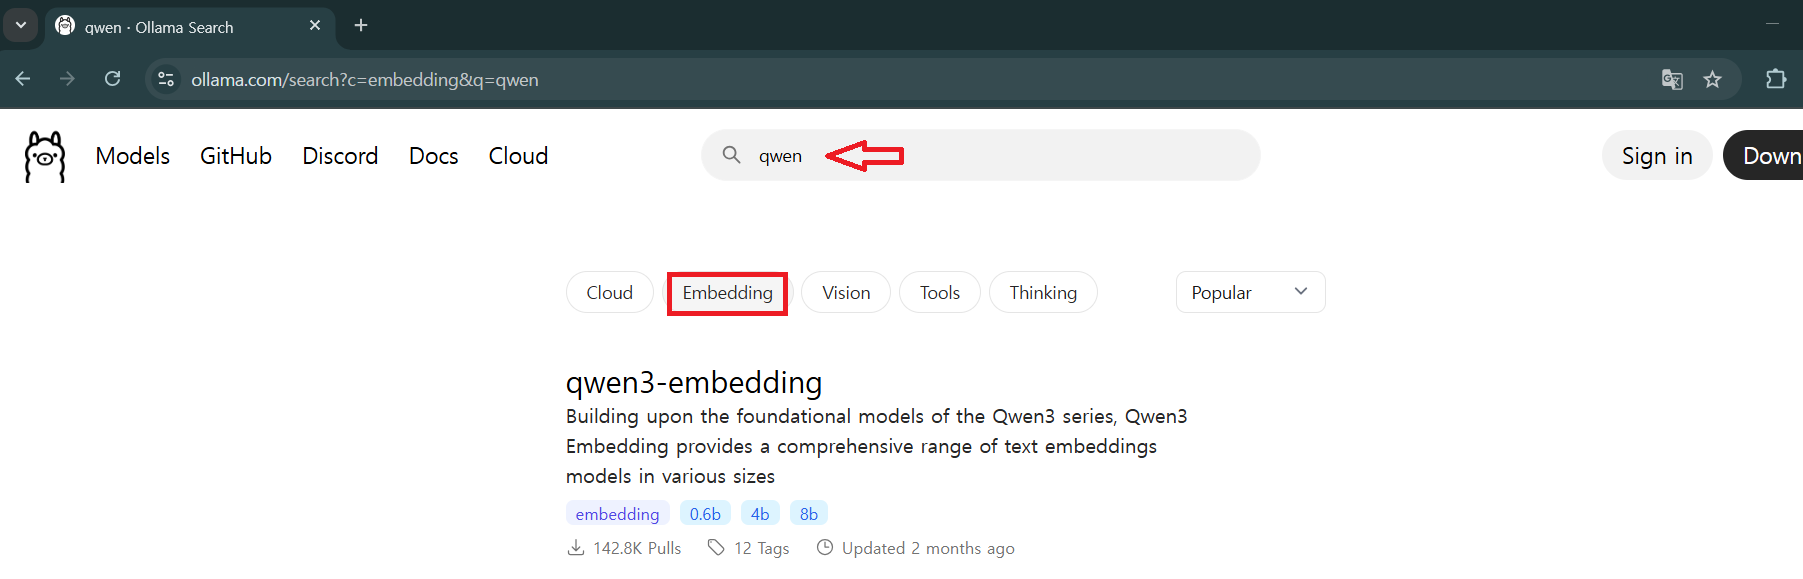

```shell
# 설치
ollama pull qwen3-embedding:0.6b

# 확인 
ollama list
```

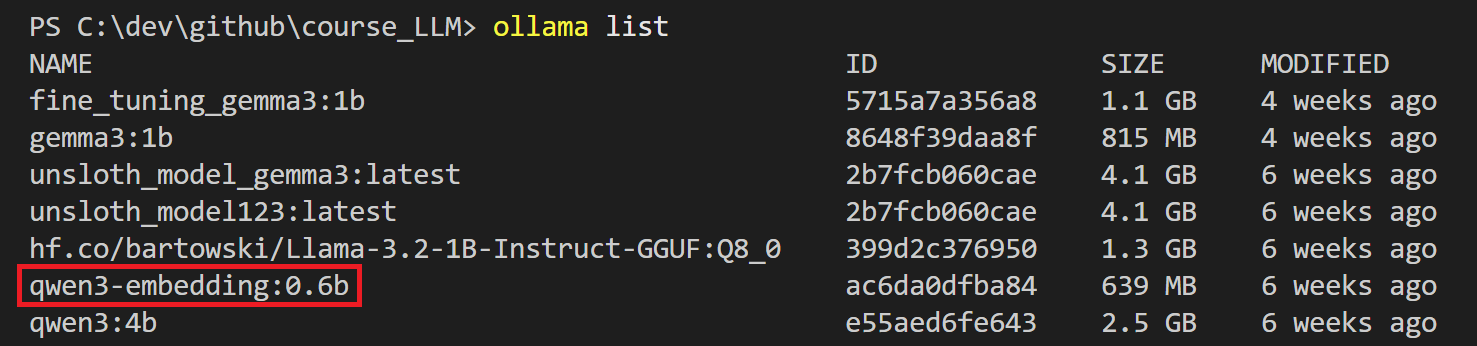

In [4]:
from langchain_ollama import OllamaEmbeddings

embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [5]:
input_text = "The meaning of life is 42"
vector = embeddings_ollama.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1024


- test_embedding

In [6]:
test_embedding(embeddings_ollama)


            [유사도 0.3798] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.3833] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4712] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.2668] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.3474] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


# [그외 Embedding models](https://docs.langchain.com/oss/python/integrations/text_embedding#top-integrations)

## [Upstage](https://python.langchain.com/docs/integrations/text_embedding/upstage/)
- Upstage는 인공지능(AI) 기술, 특히 대규모 언어 모델(LLM)과 문서 AI 분야에 특화된 국내 스타트업입니다.

## [GPT4All](https://python.langchain.com/docs/integrations/text_embedding/gpt4all/)
- GPT4All은 무료로 사용할 수 있는 로컬 실행 기반의 개인정보 보호를 고려한 챗봇입니다.
- GPU나 인터넷 연결이 필요하지 않으며, GPT4All Falcon, Wizard 등 인기 있는 모델과 자체 모델을 제공합니다.

## [Google Generative AI Embeddings](https://python.langchain.com/docs/integrations/text_embedding/google_generative_ai/)
- GoogleGenerativeAIEmbeddings 클래스를 사용하면 Google의 생성형 AI 모델을 활용하여 문서나 문장을 임베딩할 수 있습니다.